# Exploratory Data Analysis — Curriculum & Job Market Datasets

**Purpose:** Understand the structure, coverage, and quality of both datasets before running the NLP skill extraction pipeline.

**Where this fits:**
```
Raw data → Cleaning/Merging → Translation → [THIS NOTEBOOK] EDA → Skill Extraction → ESCO Normalization → Alignment
```

**Key questions this notebook answers:**
- How many courses/programs per university? How balanced is the data?
- Which fields are missing? (descriptions, credits, seniority levels)
- How long is the text going into NLP? (short texts = fewer keywords)
- What do the job market sources look like? (balance, companies, seniority)

**Inputs:**
- `data/processed/university/ysu_translated.csv` — 1,161 curriculum courses
- `data/processed/jobs/final_jobs_dataset.csv` — 1,068 IT job postings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

BASE = Path.cwd().parent.parent
curr = pd.read_csv(BASE / 'data/processed/university/ysu_translated.csv')
jobs = pd.read_csv(BASE / 'data/processed/jobs/final_jobs_dataset.csv')

print(f'Curriculum: {len(curr)} rows, {len(curr.columns)} columns')
print(f'Jobs:       {len(jobs)} rows, {len(jobs.columns)} columns')

Curriculum: 1161 rows, 20 columns
Jobs:       1068 rows, 13 columns


---
## Part 1: Curriculum Dataset

### 1.1 Courses per University

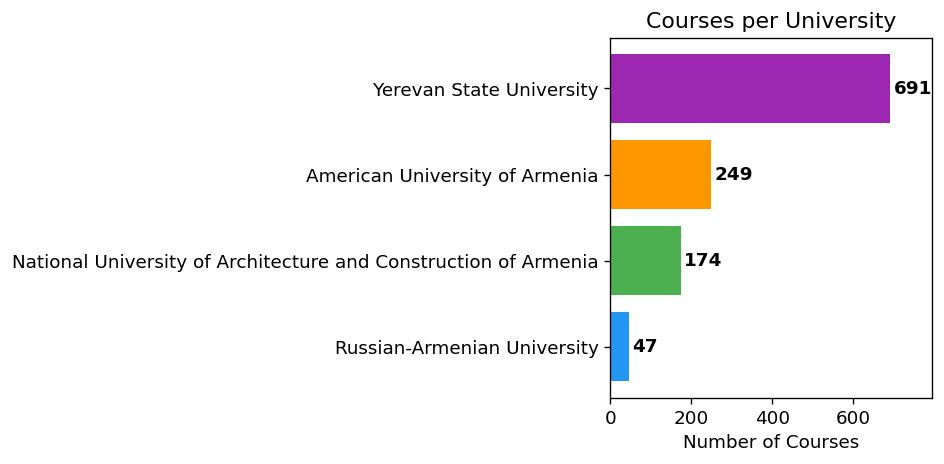

university
Yerevan State University                                           691
American University of Armenia                                     249
National University of Architecture and Construction of Armenia    174
Russian-Armenian University                                         47


In [2]:
uni_counts = curr['university'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(uni_counts.index[::-1], uni_counts.values[::-1], color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
ax.set_xlabel('Number of Courses')
ax.set_title('Courses per University')
for bar, val in zip(bars, uni_counts.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
ax.set_xlim(0, max(uni_counts.values) * 1.15)
plt.tight_layout()
plt.show()

print(uni_counts.to_string())

### 1.2 Programs per University and Degree Level

In [3]:
# Programs per university
prog_uni = curr.groupby('university')['program_name'].nunique().sort_values(ascending=False)
print('Programs per university:')
print(prog_uni.to_string())
print(f'\nTotal unique programs: {curr["program_name"].nunique()}')

# Degree level breakdown
print('\nDegree level distribution:')
print(curr['degree_level'].value_counts().to_string())

# Cross-tab: university × degree level
ct = pd.crosstab(curr['university'], curr['degree_level'], margins=True)
print('\nCourses by University × Degree Level:')
print(ct.to_string())

Programs per university:
university
Yerevan State University                                           13
American University of Armenia                                      7
National University of Architecture and Construction of Armenia     4
Russian-Armenian University                                         1

Total unique programs: 25

Degree level distribution:
degree_level
Bachelor    761
Master      373
General      27

Courses by University × Degree Level:
degree_level                                                     Bachelor  General  Master   All
university                                                                                      
American University of Armenia                                        136       27      86   249
National University of Architecture and Construction of Armenia       118        0      56   174
Russian-Armenian University                                            47        0       0    47
Yerevan State University                    

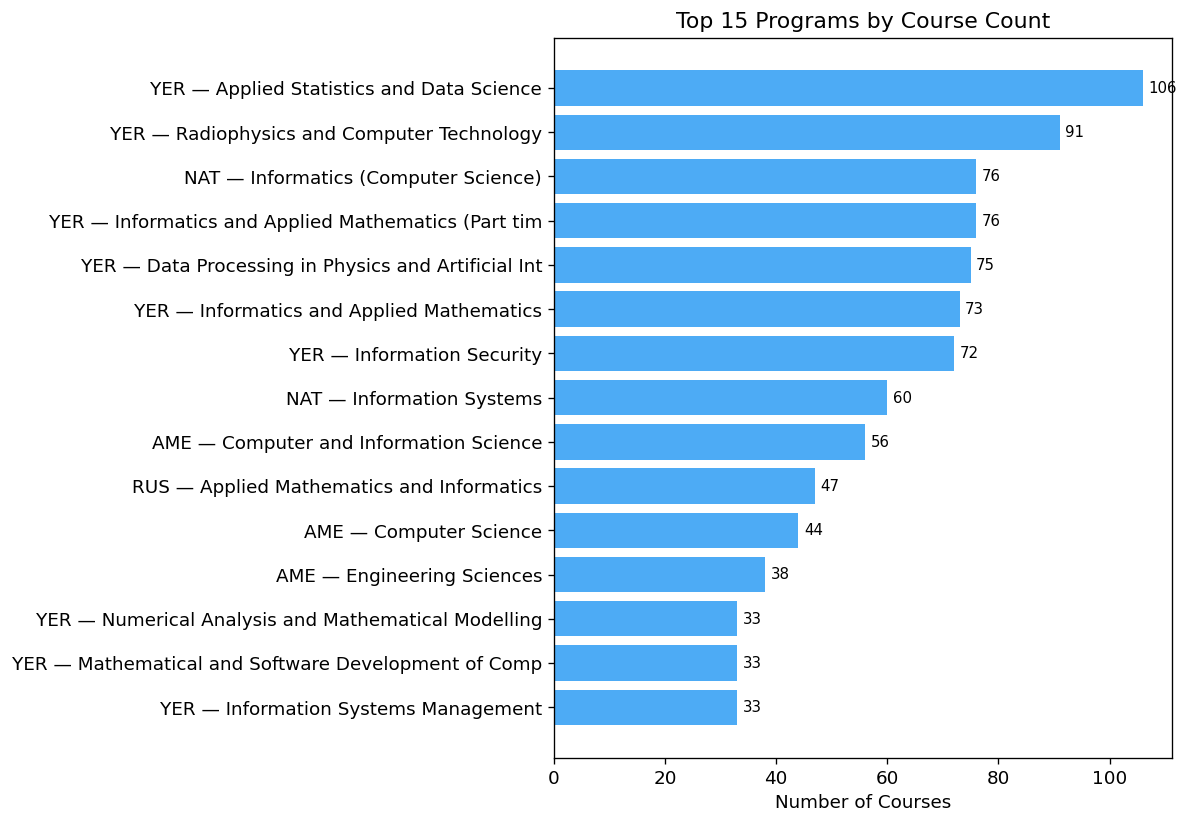

In [4]:
# Courses per program (top 15)
prog_counts = curr.groupby(['university', 'program_name']).size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top15 = prog_counts.head(15)
labels = [f'{uni[:3].upper()} — {prog[:45]}' for (uni, prog) in top15.index]
bars = ax.barh(labels[::-1], top15.values[::-1], color='#2196F3', alpha=0.8)
ax.set_xlabel('Number of Courses')
ax.set_title('Top 15 Programs by Course Count')
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 1.3 Field Coverage (Missing Values)

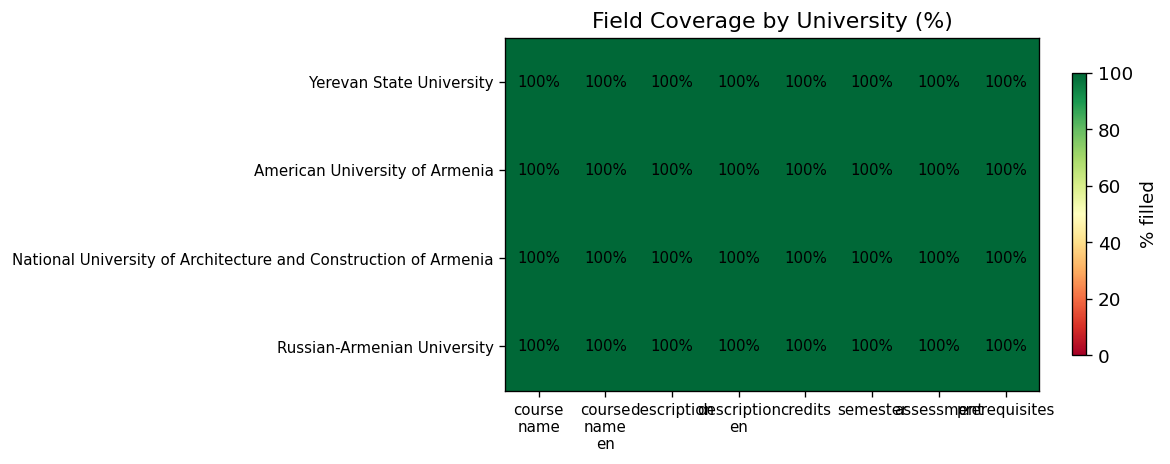

In [5]:
# Field coverage heatmap by university
key_fields = ['course_name', 'course_name_en', 'description', 'description_en',
              'credits', 'semester', 'assessment', 'prerequisites']

coverage = {}
for uni in curr['university'].unique():
    sub = curr[curr['university'] == uni]
    row = {}
    for col in key_fields:
        if col in sub.columns:
            filled = sub[col].astype(str).str.strip().ne('').sum()
            row[col] = filled / len(sub) * 100
        else:
            row[col] = 0
    coverage[uni] = row

cov_df = pd.DataFrame(coverage).T

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(cov_df.values, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(key_fields)))
ax.set_xticklabels([c.replace('_', '\n') for c in key_fields], fontsize=9)
ax.set_yticks(range(len(cov_df)))
ax.set_yticklabels(cov_df.index, fontsize=9)
for i in range(len(cov_df)):
    for j in range(len(key_fields)):
        val = cov_df.values[i, j]
        color = 'white' if val < 50 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=9, color=color)
ax.set_title('Field Coverage by University (%)')
fig.colorbar(im, ax=ax, shrink=0.8, label='% filled')
plt.tight_layout()
plt.show()

### 1.4 Credit Distribution

/var/folders/0l/7b8_ztcx19d3zxdnsypbsg1r0000gn/T/ipykernel_43542/46659007.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(credit_data, labels=credit_labels)


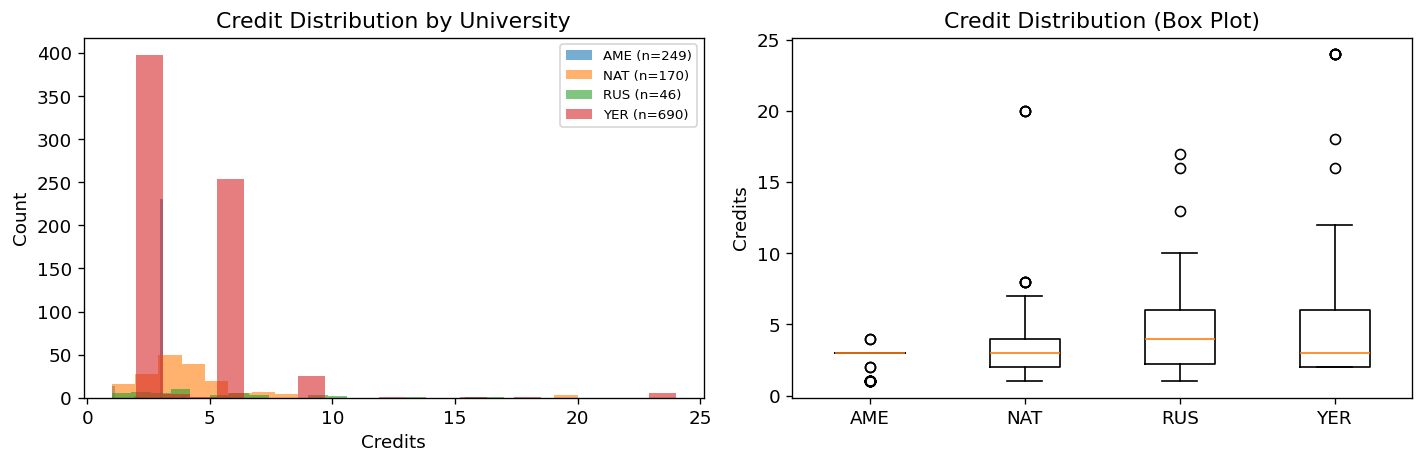

Credit statistics by university:

                                                                 count  mean  std  min  25%  50%  75%   max
university                                                                                                 
American University of Armenia                                   249.0   2.9  0.5  1.0  3.0  3.0  3.0   4.0
National University of Architecture and Construction of Armenia  170.0   3.8  2.7  1.0  2.0  3.0  4.0  20.0
Russian-Armenian University                                       46.0   5.1  3.7  1.0  2.2  4.0  6.0  17.0
Yerevan State University                                         690.0   4.2  2.7  2.0  2.0  3.0  6.0  24.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Credit distribution by university
for uni in sorted(curr['university'].unique()):
    sub = curr[(curr['university'] == uni) & (curr['credits'].notna()) & (curr['credits'] > 0)]
    if len(sub) > 0:
        axes[0].hist(sub['credits'], bins=20, alpha=0.6, label=f'{uni[:3].upper()} (n={len(sub)})')
axes[0].set_xlabel('Credits')
axes[0].set_ylabel('Count')
axes[0].set_title('Credit Distribution by University')
axes[0].legend(fontsize=8)

# Box plot
credit_data = []
credit_labels = []
for uni in sorted(curr['university'].unique()):
    sub = curr[(curr['university'] == uni) & (curr['credits'].notna()) & (curr['credits'] > 0)]
    if len(sub) > 0:
        credit_data.append(sub['credits'].values)
        credit_labels.append(uni[:3].upper())
axes[1].boxplot(credit_data, labels=credit_labels)
axes[1].set_ylabel('Credits')
axes[1].set_title('Credit Distribution (Box Plot)')

plt.tight_layout()
plt.show()

# Summary stats
print('Credit statistics by university:\n')
print(curr[curr['credits'] > 0].groupby('university')['credits'].describe().round(1).to_string())

### 1.5 Text Length Distribution (NLP Input Quality)

The text that goes into skill extraction — how long is it? Short texts yield fewer keywords.

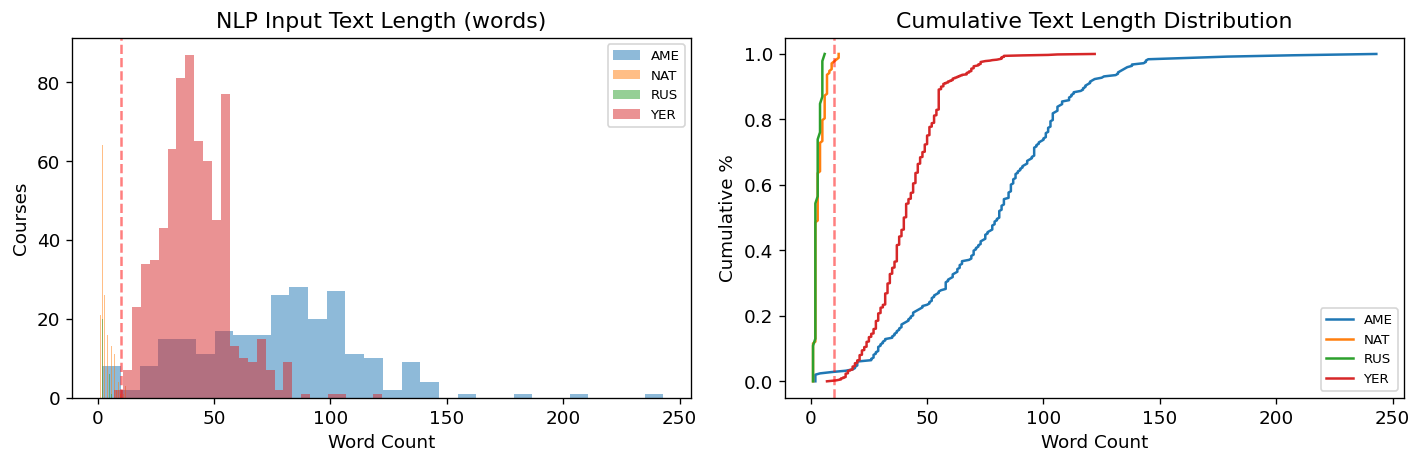

Text length statistics (word count) by university:

                                                                 count  mean   std  min   25%   50%    75%    max
university                                                                                                       
American University of Armenia                                   249.0  77.0  36.0  2.0  52.0  81.0  101.0  243.0
National University of Architecture and Construction of Armenia  174.0   4.0   2.0  1.0   2.0   3.0    5.0   12.0
Russian-Armenian University                                       47.0   3.0   1.0  1.0   2.0   2.0    4.0    6.0
Yerevan State University                                         691.0  41.0  15.0  7.0  32.0  40.0   50.0  122.0

Courses with < 10 words (name-only, no description): 226/1161


In [7]:
# Build NLP input text: course_name_en + description_en
curr['_nlp_text'] = curr['course_name_en'].astype(str).str.strip()
has_desc = curr['description_en'].astype(str).str.strip().ne('') & curr['description_en'].notna()
curr.loc[has_desc, '_nlp_text'] = curr.loc[has_desc, '_nlp_text'] + '. ' + curr.loc[has_desc, 'description_en'].astype(str)
curr['_text_len'] = curr['_nlp_text'].str.len()
curr['_word_count'] = curr['_nlp_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Text length by university
for uni in sorted(curr['university'].unique()):
    sub = curr[curr['university'] == uni]
    axes[0].hist(sub['_word_count'], bins=30, alpha=0.5, label=f'{uni[:3].upper()}')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Courses')
axes[0].set_title('NLP Input Text Length (words)')
axes[0].legend(fontsize=8)
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.5, label='Short text threshold')

# Cumulative distribution
for uni in sorted(curr['university'].unique()):
    sub = curr[curr['university'] == uni]['_word_count'].sort_values()
    axes[1].plot(sub.values, np.linspace(0, 1, len(sub)), label=f'{uni[:3].upper()}')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Text Length Distribution')
axes[1].legend(fontsize=8)
axes[1].axvline(x=10, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Stats
print('Text length statistics (word count) by university:\n')
print(curr.groupby('university')['_word_count'].describe().round(0).to_string())
print(f'\nCourses with < 10 words (name-only, no description): {(curr["_word_count"] < 10).sum()}/{len(curr)}')

### 1.6 Source Language Distribution

Source language by university:

source_language                                                  Armenian  English  Russian
university                                                                                 
American University of Armenia                                          0      249        0
National University of Architecture and Construction of Armenia         0      174        0
Russian-Armenian University                                             0        0       47
Yerevan State University                                              691        0        0


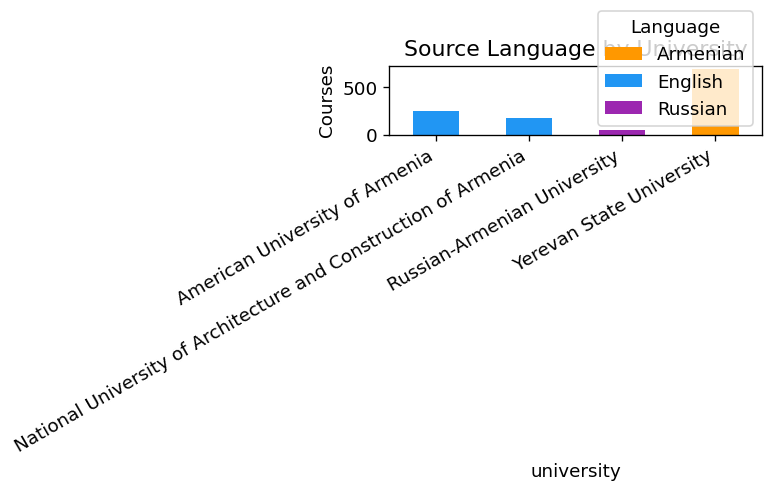

In [8]:
lang_uni = pd.crosstab(curr['university'], curr['source_language'])
print('Source language by university:\n')
print(lang_uni.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
lang_uni.plot(kind='bar', stacked=True, ax=ax, color=['#FF9800', '#2196F3', '#9C27B0'])
ax.set_ylabel('Courses')
ax.set_title('Source Language by University')
ax.legend(title='Language')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Part 2: Job Market Dataset

### 2.1 Postings per Source

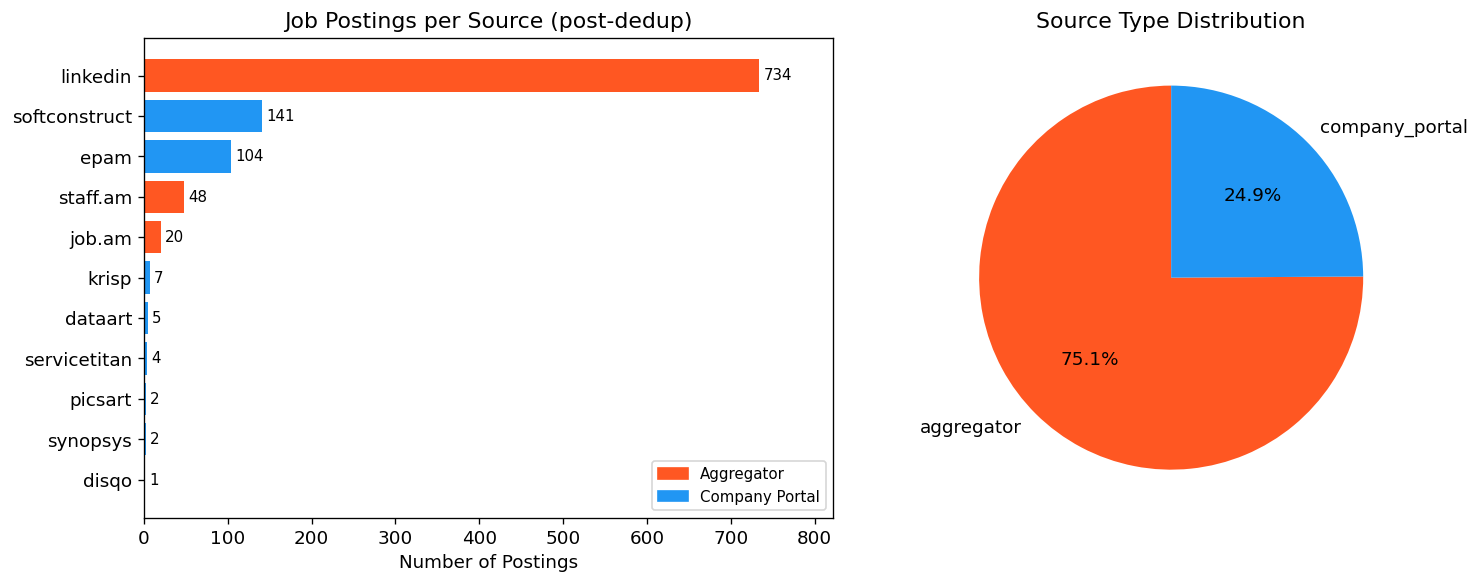

In [9]:
src_counts = jobs['source'].value_counts()
src_types = jobs.drop_duplicates('source').set_index('source')['source_type']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart by source
colors = ['#FF5722' if src_types.get(s) == 'aggregator' else '#2196F3' for s in src_counts.index]
bars = axes[0].barh(src_counts.index[::-1], src_counts.values[::-1],
                     color=colors[::-1])
axes[0].set_xlabel('Number of Postings')
axes[0].set_title('Job Postings per Source (post-dedup)')
for bar, val in zip(bars, src_counts.values[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
axes[0].set_xlim(0, max(src_counts.values) * 1.12)
# Legend
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#FF5722', label='Aggregator'),
                         Patch(color='#2196F3', label='Company Portal')], fontsize=9)

# Pie chart: aggregator vs company portal
type_counts = jobs['source_type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#FF5722', '#2196F3'], startangle=90)
axes[1].set_title('Source Type Distribution')

plt.tight_layout()
plt.show()

### 2.2 Top Companies by Posting Count

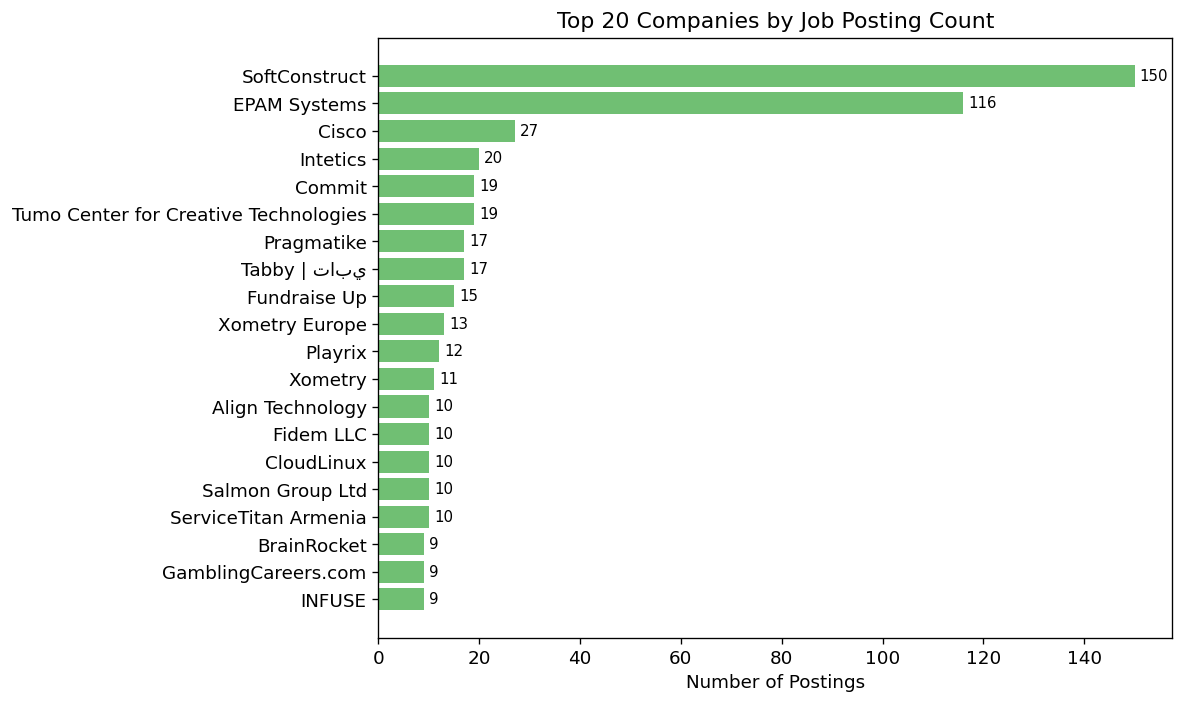

Total unique companies: 316


In [10]:
top_companies = jobs['company_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_companies.index[::-1], top_companies.values[::-1], color='#4CAF50', alpha=0.8)
ax.set_xlabel('Number of Postings')
ax.set_title('Top 20 Companies by Job Posting Count')
for bar, val in zip(bars, top_companies.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total unique companies: {jobs["company_name"].nunique()}')

### 2.3 Seniority Level & Employment Type

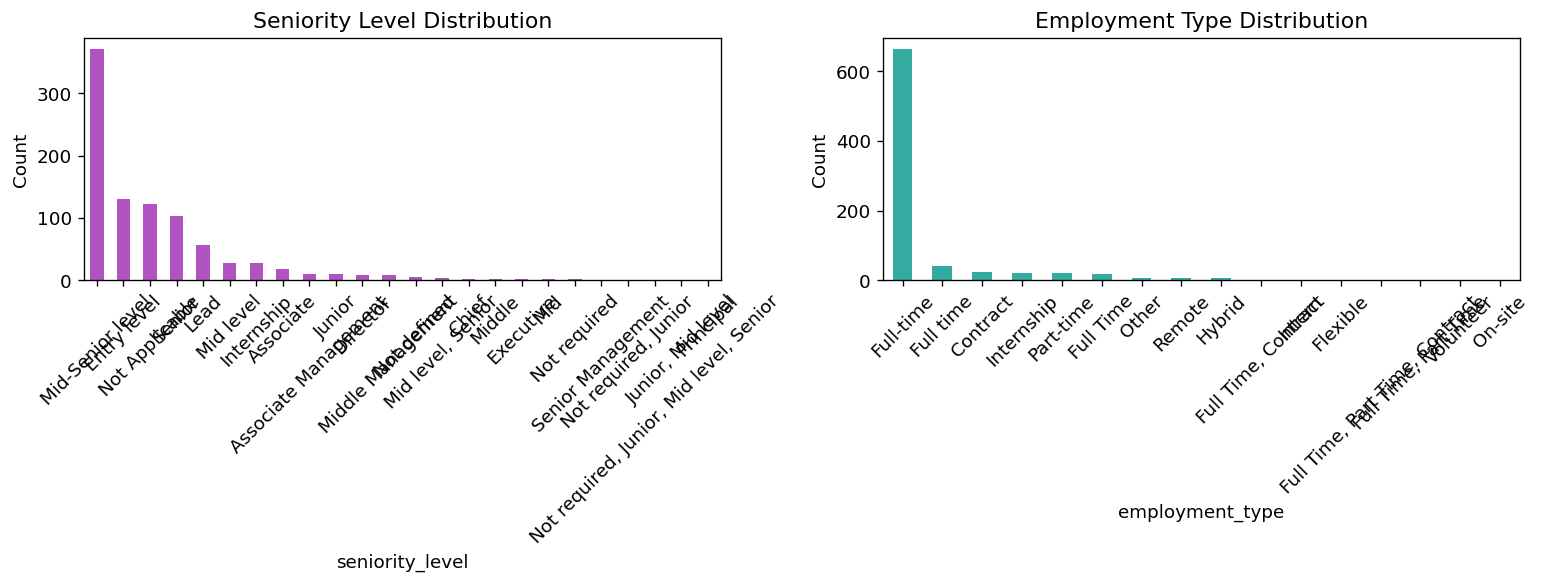

Seniority filled: 24 levels, 919/1068 rows
Employment type filled: 816/1068 rows


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Seniority
sen = jobs['seniority_level'].replace('', np.nan).dropna().value_counts()
sen.plot(kind='bar', ax=axes[0], color='#9C27B0', alpha=0.8)
axes[0].set_title('Seniority Level Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Employment type
emp = jobs['employment_type'].replace('', np.nan).dropna().value_counts()
emp.plot(kind='bar', ax=axes[1], color='#009688', alpha=0.8)
axes[1].set_title('Employment Type Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Seniority filled: {len(sen.index)} levels, {jobs["seniority_level"].replace("", np.nan).notna().sum()}/{len(jobs)} rows')
print(f'Employment type filled: {jobs["employment_type"].replace("", np.nan).notna().sum()}/{len(jobs)} rows')

### 2.4 Job Description Text Length (NLP Input Quality)

/var/folders/0l/7b8_ztcx19d3zxdnsypbsg1r0000gn/T/ipykernel_43542/363352273.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(bp_data, labels=top5_sources)


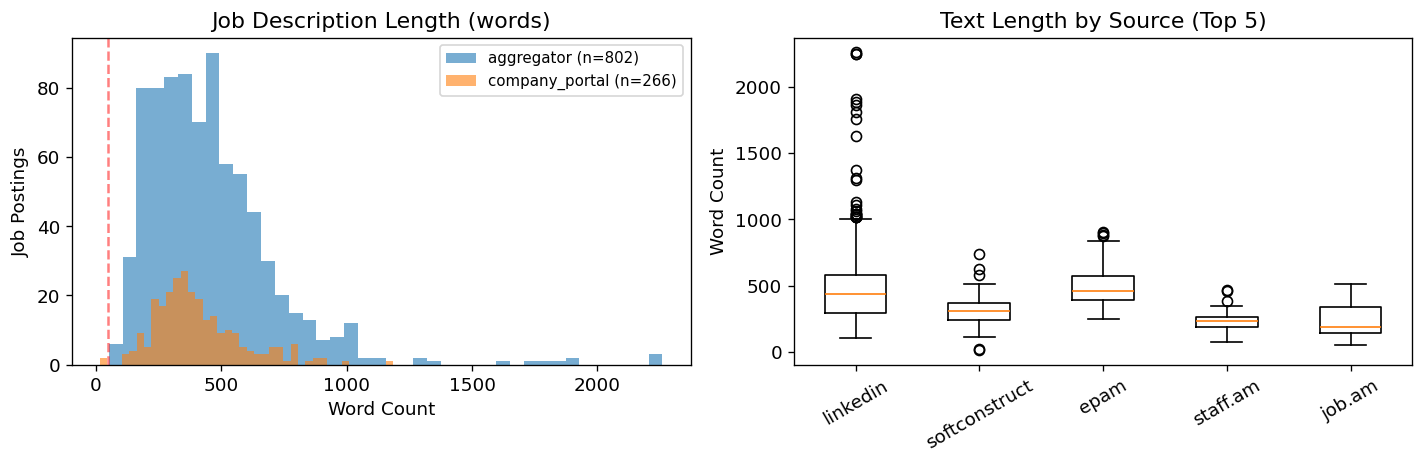

Job text length statistics (words):

                count   mean    std   min    25%    50%    75%     max
source_type                                                           
aggregator      802.0  455.0  269.0  51.0  274.0  416.0  568.0  2259.0
company_portal  266.0  405.0  176.0  16.0  288.0  368.0  485.0  1186.0

Jobs with < 50 words: 2/1068


In [12]:
jobs['_word_count'] = jobs['full_text'].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram by source type
for st in ['aggregator', 'company_portal']:
    sub = jobs[jobs['source_type'] == st]
    axes[0].hist(sub['_word_count'], bins=40, alpha=0.6, label=f'{st} (n={len(sub)})')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Job Postings')
axes[0].set_title('Job Description Length (words)')
axes[0].legend(fontsize=9)
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5)

# Box plot by source (top 5 sources only)
top5_sources = jobs['source'].value_counts().head(5).index
bp_data = [jobs[jobs['source'] == s]['_word_count'].values for s in top5_sources]
axes[1].boxplot(bp_data, labels=top5_sources)
axes[1].set_ylabel('Word Count')
axes[1].set_title('Text Length by Source (Top 5)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Job text length statistics (words):\n')
print(jobs.groupby('source_type')['_word_count'].describe().round(0).to_string())
print(f'\nJobs with < 50 words: {(jobs["_word_count"] < 50).sum()}/{len(jobs)}')

### 2.5 Jobs Field Coverage

In [13]:
print('Jobs field coverage:\n')
for col in jobs.columns:
    if col.startswith('_'):
        continue
    filled = jobs[col].astype(str).str.strip().ne('').sum()
    pct = filled / len(jobs) * 100
    bar = '#' * int(pct / 2.5)
    print(f'  {col:20} {filled:>5}/{len(jobs)}  ({pct:5.1f}%)  {bar}')

Jobs field coverage:

  source                1068/1068  (100.0%)  ########################################
  source_type           1068/1068  (100.0%)  ########################################
  source_url            1068/1068  (100.0%)  ########################################
  job_title             1068/1068  (100.0%)  ########################################
  company_name          1068/1068  (100.0%)  ########################################
  location              1068/1068  (100.0%)  ########################################
  employment_type       1068/1068  (100.0%)  ########################################
  seniority_level       1068/1068  (100.0%)  ########################################
  industries            1068/1068  (100.0%)  ########################################
  posting_date          1068/1068  (100.0%)  ########################################
  deadline              1068/1068  (100.0%)  ########################################
  skills_tags           1068/106

---
## Part 3: Pre-NLP Readiness Summary

In [14]:
# ── Dataset overview table ─────────────────────────────────────────────
curr_desc_pct = has_desc.sum() / len(curr) * 100
curr_short = (curr['_word_count'] < 10).sum()
jobs_short = (jobs['_word_count'] < 50).sum()

print('╔══════════════════════════════════════════════════════════════════╗')
print('║              PRE-NLP DATASET READINESS SUMMARY                  ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  CURRICULUM                                                     ║')
print(f'║    Total courses:         {len(curr):>6}                                ║')
print(f'║    Universities:          {curr["university"].nunique():>6}                                ║')
print(f'║    Programs:              {curr["program_name"].nunique():>6}                                ║')
print(f'║    Has description:       {has_desc.sum():>6} ({curr_desc_pct:.0f}%)                          ║')
print(f'║    English translation:   {curr["course_name_en"].notna().sum():>6} ({curr["course_name_en"].notna().sum()/len(curr)*100:.0f}%)                          ║')
print(f'║    Short text (<10 words): {curr_short:>5} (mostly NUACA/RAU, name-only)    ║')
print(f'║                                                                 ║')
print(f'║  JOBS                                                           ║')
print(f'║    Total postings:        {len(jobs):>6} (post-dedup)                     ║')
print(f'║    Sources:               {jobs["source"].nunique():>6}                                ║')
print(f'║    Unique companies:      {jobs["company_name"].nunique():>6}                                ║')
print(f'║    full_text coverage:       100%                               ║')
print(f'║    Median text length:    {jobs["_word_count"].median():.0f} words                          ║')
print(f'║    Short text (<50 words): {jobs_short:>5}                                ║')
print(f'║                                                                 ║')
print(f'║  NLP INPUT READY: Both datasets have sufficient text for        ║')
print(f'║  keyword extraction. Short-text courses (NUACA, RAU) will       ║')
print(f'║  yield fewer keywords — this is expected and documented.        ║')
print('╚══════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════╗
║              PRE-NLP DATASET READINESS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════╣
║  CURRICULUM                                                     ║
║    Total courses:           1161                                ║
║    Universities:               4                                ║
║    Programs:                  25                                ║
║    Has description:          933 (80%)                          ║
║    English translation:     1160 (100%)                          ║
║    Short text (<10 words):   226 (mostly NUACA/RAU, name-only)    ║
║                                                                 ║
║  JOBS                                                           ║
║    Total postings:          1068 (post-dedup)                     ║
║    Sources:                   11                                ║
║    Unique companies:         316       